# Quarterly horizon refactor, Return RF v6 training

**Purpose.** Retrain the Return Random Forest at the new quarterly (63-trading-day) target horizon, with the full grid search visible in-notebook for academic proof of work. Mirrors the structure of `model.ipynb` (which trained v5 at monthly horizon).

**What is unchanged from v5:**
- The seven post-correlation-audit features (`momentum`, `volatility_21d`, `drawdown_52w`, `relative_strength`, `volume_ratio_20`, `beta_252`, `vix`).
- The cleaned-prices universe (93 FTSE 100 stocks after the seven quality-filter exclusions, late-listing CTEC.L and AUTO.L retained with leading NaN preserved per the no-bfill policy).
- The chronological train/test split (pre-2024 tuning, 2024-01-01 onwards held-out).
- The hyperparameter grid (`max_depth ∈ {5, 8}`, `min_samples_leaf ∈ {50, 100, 200}`, `max_features ∈ {2, 3, sqrt, 0.5}`, `n_estimators = 500`).
- The `PurgedTimeSeriesSplit` cross-validator with date-level purging.
- The Spearman ρ primary scoring metric.

**What is changed:**
- Target window: 21 → **63** trading days for both `forward_return` and `forward_volatility` (in `src/features/engineer.py`).
- CV embargo: 5 → **63** trading days (widened to match the new target window per López de Prado, 2018).

**Why quarterly.** Held-out monthly Return RF (v5) achieved Spearman ρ ≈ 0.02, barely above noise. The asset-pricing literature reports that equity return forecasts at longer horizons exhibit better R² and directional accuracy (Gu, Kelly & Xiu, 2020). Step 2 of the horizon refactor tests this empirically.

**Note on runtime.** The grid search cell below executes the full 24-configuration × 5-fold = 120-fit grid in-notebook. Expected runtime ≈ 55 minutes. This is intentional, the notebook is the academic proof of work; the equivalent standalone script (`scripts/retrain_return_rf_quarterly.py`) exists for automation.

In [1]:
import sys
import warnings
from pathlib import Path
import time

warnings.filterwarnings('ignore')
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import spearmanr

from src.data.ingest import load_or_build_clean_prices
from src.features.engineer import build_features

import sklearn, scipy
print(f'sklearn {sklearn.__version__}  |  scipy {scipy.__version__}  |  pandas {pd.__version__}  |  numpy {np.__version__}')

sklearn 1.8.0  |  scipy 1.17.0  |  pandas 2.3.3  |  numpy 2.3.5


## 1. Load cleaned prices and rebuild features

`build_features()` reads from `src/features/engineer.py`, which has been updated at lines 104–106 to compute forward targets over a 63-day window. The cell below regenerates `features.parquet` from the cleaned prices and verifies the new target shape.

In [2]:
raw_path = Path('../data/raw/prices.parquet')
clean_path = Path('../data/processed/prices_clean.parquet')
features_path = Path('../data/processed/features.parquet')

clean = load_or_build_clean_prices(raw_path, clean_path)
print(f'cleaned prices: {clean.shape[0]} dates × {clean.shape[1]} (price + volume) columns')

t0 = time.time()
feature_df = build_features(clean)
feature_clean = feature_df.dropna()
feature_clean.to_parquet(features_path)
print(f'features built in {time.time()-t0:.1f}s')
print(f'features_clean: {len(feature_clean):,} rows × {feature_clean.shape[1]} columns')
print(f'date range:    {feature_clean.index.get_level_values("date").min().date()}  →  {feature_clean.index.get_level_values("date").max().date()}')
print(f'tickers:       {feature_clean.index.get_level_values("ticker").nunique()}')

# Sanity-check the forward_return target on one ticker
sample_ticker = 'HSBA.L'
sample_date = feature_clean.xs(sample_ticker, level='ticker').index[-100]
manual_fwd = clean['Close'][sample_ticker].shift(-63) / clean['Close'][sample_ticker] - 1
fwd_features = feature_clean.loc[(sample_date, sample_ticker), 'forward_return']
print(f'\nspot-check {sample_ticker} on {sample_date.date()}:')
print(f'  manual 63-day pct_change: {manual_fwd.loc[sample_date]:+.6f}')
print(f'  features forward_return:  {fwd_features:+.6f}')
assert abs(manual_fwd.loc[sample_date] - fwd_features) < 1e-10, 'Target mismatch, investigate'
print('  match (within 1e-10): OK')

cleaned prices: 2928 dates × 190 (price + volume) columns
features built in 1.6s
features_clean: 242,488 rows × 9 columns
date range:    2015-12-24  →  2026-02-20
tickers:       93

spot-check HSBA.L on 2025-10-02:
  manual 63-day pct_change: +0.124838
  features forward_return:  +0.124838
  match (within 1e-10): OK


## 2. Train/test split

Chronological split, unchanged from v5: pre-2024 for tuning, 2024-01-01 onwards held out for a single final evaluation pass.

In [3]:
FEATURE_COLS = [
    'momentum', 'volatility_21d', 'drawdown_52w',
    'relative_strength', 'volume_ratio_20', 'beta_252', 'vix',
]

cutoff = pd.Timestamp('2024-01-01')
date_level = feature_clean.index.get_level_values('date')
tuning = feature_clean[date_level < cutoff]
held_out = feature_clean[date_level >= cutoff]

X_tune, y_tune = tuning[FEATURE_COLS], tuning['forward_return']
X_held, y_held = held_out[FEATURE_COLS], held_out['forward_return']

print(f'Tuning (pre-2024):   {len(X_tune):,} rows, {tuning.index.get_level_values("date").nunique()} dates')
print(f'Held-out (2024-01-01+): {len(X_held):,} rows, {held_out.index.get_level_values("date").nunique()} dates')

Tuning (pre-2024):   191,245 rows, 2062 dates
Held-out (2024-01-01+): 51,243 rows, 551 dates


## 3. Purged TimeSeriesSplit with widened embargo

The class below mirrors `model.ipynb`'s definition with two changes to defaults:
- `horizon_td = 63` (matches the new target window length)
- `embargo_td = 63` (widened from 5 per Kai's brief to fully prevent target-window overlap between train and validation folds)

Purging operates at the date level: any training date `t` whose forward target `[t, t+63]` overlaps the validation window (plus the embargo) is removed entirely (across all tickers on that date). This treatment of cross-sectional dependence follows López de Prado (2018, Ch. 7).

In [4]:
HORIZON_TD = 63
EMBARGO_TD = 63
N_SPLITS = 5


class PurgedTimeSeriesSplit:
    """TimeSeriesSplit with purging + embargo to prevent target-window leakage."""

    def __init__(self, n_splits=N_SPLITS, horizon_td=HORIZON_TD, embargo_td=EMBARGO_TD):
        self.n_splits = n_splits
        self.horizon_td = horizon_td
        self.embargo_td = embargo_td

    def split(self, X, y=None, groups=None):
        dates = X.index.get_level_values('date').unique().sort_values()
        date_to_pos = {d: i for i, d in enumerate(dates)}
        tscv = TimeSeriesSplit(n_splits=self.n_splits)

        for train_dates_idx, val_dates_idx in tscv.split(dates):
            val_dates_arr = dates[val_dates_idx]
            val_start_pos = date_to_pos[val_dates_arr[0]]

            purge_start_pos = max(0, val_start_pos - self.horizon_td - self.embargo_td)
            purge_dates = set(dates[purge_start_pos:val_start_pos])
            train_dates_set = set(dates[train_dates_idx]) - purge_dates

            d_level = X.index.get_level_values('date')
            train_mask = d_level.isin(train_dates_set)
            val_mask = d_level.isin(set(val_dates_arr))

            yield np.where(train_mask)[0], np.where(val_mask)[0]

    def get_n_splits(self, X=None, y=None, groups=None):
        return self.n_splits


# Smoke-check: print the purge effect on the first fold
cv_check = PurgedTimeSeriesSplit()
for fold_i, (tr_idx, vl_idx) in enumerate(cv_check.split(X_tune)):
    n_dates_tune = tuning.index.get_level_values('date').nunique()
    tr_dates = X_tune.iloc[tr_idx].index.get_level_values('date').nunique()
    vl_dates = X_tune.iloc[vl_idx].index.get_level_values('date').nunique()
    purged = (n_dates_tune * fold_i // 5) - tr_dates if fold_i > 0 else 0
    print(f'fold {fold_i+1}: {tr_dates} train dates | {vl_dates} val dates | {len(tr_idx):,} train rows | {len(vl_idx):,} val rows')

fold 1: 221 train dates | 343 val dates | 20,278 train rows | 31,779 val rows
fold 2: 564 train dates | 343 val dates | 51,931 train rows | 31,899 val rows
fold 3: 907 train dates | 343 val dates | 83,830 train rows | 31,899 val rows
fold 4: 1250 train dates | 343 val dates | 115,729 train rows | 31,899 val rows
fold 5: 1593 train dates | 343 val dates | 147,628 train rows | 31,899 val rows


## 4. Baselines

Two reference points for the held-out evaluation:
- **Historical-mean** baseline: predict the in-sample mean for every held-out observation.
- **Always-positive** baseline (for directional accuracy): predict +1 for every held-out observation. Since quarterly equity returns are positive ~60% of the time (the equity risk premium accumulates), this is a non-trivial floor for the model to beat.

In [5]:
y_tune_mean = float(y_tune.mean())
print(f'In-sample mean forward_return: {y_tune_mean:+.6f}  (≈ {y_tune_mean*100:.3f}% per quarter)')

# Historical-mean baseline metrics on held-out
baseline_pred = np.full_like(y_held.to_numpy(), y_tune_mean)
rmse_baseline = float(np.sqrt(mean_squared_error(y_held, baseline_pred)))
r2_baseline = float(r2_score(y_held, baseline_pred))
always_pos = np.ones_like(y_held.to_numpy())
dir_acc_baseline = float(np.mean(np.sign(y_held.to_numpy()) == np.sign(always_pos)))

print(f'\nBaselines on held-out (n={len(y_held):,}):')
print(f'  RMSE (historical-mean):              {rmse_baseline:.6f}')
print(f'  R² (historical-mean):                {r2_baseline:+.6f}')
print(f'  Directional accuracy (always-positive): {dir_acc_baseline:.4f}')

In-sample mean forward_return: +0.020885  (≈ 2.088% per quarter)

Baselines on held-out (n=51,243):
  RMSE (historical-mean):              0.138160
  R² (historical-mean):                -0.013976
  Directional accuracy (always-positive): 0.6055


## 5. Grid search (purged 5-fold CV, Spearman ρ scoring)

The grid below is identical to v5's: 24 hyperparameter combinations × 5 CV folds = 120 fits. Primary metric is Spearman ρ (the relevant signal for the optimiser, which uses rank ordering rather than absolute return predictions).

**Runtime: ~55 minutes on a typical laptop** (`n_jobs=-1` on the RF; one CV fold at a time at the outer GridSearchCV level).

In [6]:
GRID = {
    'max_depth':        [5, 8],
    'min_samples_leaf': [50, 100, 200],
    'max_features':     [2, 3, 'sqrt', 0.5],
}


def spearman_score(y_true, y_pred) -> float:
    rho, _ = spearmanr(y_true, y_pred)
    return float(rho) if not np.isnan(rho) else 0.0


SPEARMAN_SCORER = make_scorer(spearman_score, greater_is_better=True)

base = RandomForestRegressor(n_estimators=500, random_state=42, n_jobs=-1)
cv = PurgedTimeSeriesSplit(n_splits=N_SPLITS, horizon_td=HORIZON_TD, embargo_td=EMBARGO_TD)

grid = GridSearchCV(
    estimator=base,
    param_grid=GRID,
    cv=cv,
    scoring=SPEARMAN_SCORER,
    n_jobs=1,
    verbose=1,
    refit=True,
)

t0 = time.time()
grid.fit(X_tune, y_tune)
elapsed_min = (time.time() - t0) / 60
print(f'\nGrid search completed in {elapsed_min:.1f} minutes')
print(f'Best CV Spearman ρ: {grid.best_score_:+.4f}')
print(f'Best params:        {grid.best_params_}')

Fitting 5 folds for each of 24 candidates, totalling 120 fits

Grid search completed in 75.8 minutes
Best CV Spearman ρ: +0.1527
Best params:        {'max_depth': 5, 'max_features': 3, 'min_samples_leaf': 50}


In [7]:
# Sorted ranking of all 24 configurations by mean CV Spearman ρ
cv_results = pd.DataFrame(grid.cv_results_)
param_cols = [c for c in cv_results.columns if c.startswith('param_')]
ranked = cv_results[param_cols + ['mean_test_score', 'std_test_score', 'rank_test_score']].copy()
ranked.columns = [c.replace('param_', '') for c in param_cols] + ['mean_cv_rho', 'std_cv_rho', 'rank']
ranked = ranked.sort_values('rank').reset_index(drop=True)
print('Top 10 configurations by mean CV Spearman ρ:')
print(ranked.head(10).to_string(index=False, float_format=lambda x: f'{x:+.4f}'))

Top 10 configurations by mean CV Spearman ρ:
 max_depth max_features  min_samples_leaf  mean_cv_rho  std_cv_rho  rank
         5            3                50      +0.1527     +0.1502     1
         5      +0.5000                50      +0.1527     +0.1502     1
         5      +0.5000               200      +0.1512     +0.1487     3
         5            3               200      +0.1512     +0.1487     3
         5            3               100      +0.1511     +0.1494     5
         5      +0.5000               100      +0.1511     +0.1494     5
         5         sqrt                50      +0.1508     +0.1513     7
         5            2                50      +0.1508     +0.1513     7
         5            2               100      +0.1505     +0.1504     9
         5         sqrt               100      +0.1505     +0.1504     9


## 6. Held-out evaluation of the best model

In [8]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_held)
y_held_arr = y_held.to_numpy()

rmse = float(np.sqrt(mean_squared_error(y_held_arr, y_pred)))
mae = float(mean_absolute_error(y_held_arr, y_pred))
r2 = float(r2_score(y_held_arr, y_pred))
spear = spearman_score(y_held_arr, y_pred)
dir_acc = float(np.mean(np.sign(y_held_arr) == np.sign(y_pred)))

print(f'Held-out evaluation (2024-01-01 onwards, n = {len(y_held_arr):,}):\n')
print(f'  RMSE:                 {rmse:.6f}    (baseline {rmse_baseline:.6f})')
print(f'  MAE:                  {mae:.6f}')
print(f'  R²:                   {r2:+.6f}    (baseline {r2_baseline:+.6f})')
print(f'  Spearman ρ:           {spear:+.6f}')
print(f'  Directional accuracy: {dir_acc:.4f}        (baseline {dir_acc_baseline:.4f})')

# Sanity-check bounds from Kai's brief
print('\nSanity checks:')
if r2 > 0.20:
    print(f'  STOP: R² {r2:+.4f} > 0.20, investigate look-ahead immediately')
elif r2 > 0.05:
    print(f'  WARN: R² {r2:+.4f} > 0.05, flag for review')
elif r2 < 0.005:
    print(f'  NOTE: R² {r2:+.4f} below 0.005, weak signal, defensible for return prediction')
else:
    print(f'  OK:   R² {r2:+.4f} in expected range [0.005, 0.05]')

if dir_acc > 0.65:
    print(f'  WARN: directional accuracy {dir_acc:.4f} > 0.65, flag for review')
elif dir_acc < 0.50:
    print(f'  NOTE: directional accuracy {dir_acc:.4f} < 0.50, worse than coin flip')
else:
    print(f'  OK:   directional accuracy {dir_acc:.4f} in expected range [0.50, 0.65]')

Held-out evaluation (2024-01-01 onwards, n = 51,243):

  RMSE:                 0.137088    (baseline 0.138160)
  MAE:                  0.103080
  R²:                   +0.001698    (baseline -0.013976)
  Spearman ρ:           +0.087842
  Directional accuracy: 0.5794        (baseline 0.6055)

Sanity checks:
  NOTE: R² +0.0017 below 0.005 — weak signal, defensible for return prediction
  OK:   directional accuracy 0.5794 in expected range [0.50, 0.65]


In [9]:
# Save the v6 Return RF artefact
model_path = Path('../models/rf_return_v6.joblib')
joblib.dump(best_model, model_path)
print(f'Saved: {model_path}')

Saved: ../models/rf_return_v6.joblib


## 7. v5 (monthly) vs v6 (quarterly), side-by-side comparison

RMSE and MAE are higher at the quarterly horizon because quarterly returns are larger in absolute magnitude than monthly returns (a quarter's σ is roughly √3 × a month's σ). The interpretive metrics, R², Spearman ρ, directional accuracy, are comparable across horizons.

v5 figures below are reproduced from the prior held-out evaluation documented in `docs/methodology.md` §4.4.

In [10]:
v5_metrics = {
    'RMSE':                  0.0800,
    'MAE':                   0.0593,
    'R²':                   -0.0030,
    'Spearman ρ':            0.0200,
    'Directional accuracy':  0.5568,
}
v5_baselines = {
    'RMSE baseline':                 0.0800,
    'R² baseline':                  -0.0030,
    'Directional baseline (alw-pos)': 0.5607,
}
v6_metrics = {
    'RMSE': rmse, 'MAE': mae, 'R²': r2, 'Spearman ρ': spear, 'Directional accuracy': dir_acc,
}
v6_baselines = {
    'RMSE baseline': rmse_baseline, 'R² baseline': r2_baseline,
    'Directional baseline (alw-pos)': dir_acc_baseline,
}

comparison = pd.DataFrame({
    'v5 (monthly)': v5_metrics,
    'v6 (quarterly)': v6_metrics,
})
baselines_df = pd.DataFrame({
    'v5 (monthly)': v5_baselines,
    'v6 (quarterly)': v6_baselines,
})

print('Model metrics:')
print(comparison.to_string(float_format=lambda x: f'{x:+.4f}'))
print('\nBaselines:')
print(baselines_df.to_string(float_format=lambda x: f'{x:+.4f}'))

Model metrics:
                      v5 (monthly)  v6 (quarterly)
RMSE                       +0.0800         +0.1371
MAE                        +0.0593         +0.1031
R²                         -0.0030         +0.0017
Spearman ρ                 +0.0200         +0.0878
Directional accuracy       +0.5568         +0.5794

Baselines:
                                v5 (monthly)  v6 (quarterly)
RMSE baseline                        +0.0800         +0.1382
R² baseline                          -0.0030         -0.0140
Directional baseline (alw-pos)       +0.5607         +0.6055


## 8. SHAP analysis on the v6 Return RF

Following the v5 notebook's approach: compute SHAP attributions on a representative sample of cross-sections from the held-out window (one snapshot per calendar month), then aggregate into a mean-|SHAP| ranking. `tree_path_dependent` perturbation chosen for consistency with `src/models/explain.py` and the dashboard's runtime SHAP cache.

In [11]:
import shap
print(f'shap {shap.__version__}')

# Build SHAP sample: one cross-section per calendar month in the held-out window
held_out_dates = sorted(held_out.index.get_level_values('date').unique())
months_df = pd.DataFrame({'date': held_out_dates})
months_df['ym'] = months_df['date'].dt.to_period('M')
sample_dates = sorted(months_df.groupby('ym')['date'].max().tolist())

shap_sample_rows = held_out[held_out.index.get_level_values('date').isin(sample_dates)]
X_shap = shap_sample_rows[FEATURE_COLS]
print(f'SHAP sample: {len(X_shap):,} rows ({len(sample_dates)} dates × {shap_sample_rows.index.get_level_values("ticker").nunique()} tickers)')

shap 0.51.0
SHAP sample: 2,418 rows (26 dates × 93 tickers)


In [12]:
explainer = shap.TreeExplainer(best_model, feature_perturbation='tree_path_dependent')

t0 = time.time()
shap_values = explainer.shap_values(X_shap)
base_value = float(np.asarray(explainer.expected_value).flat[0])
predictions = best_model.predict(X_shap)
print(f'SHAP computed in {time.time()-t0:.1f}s for {X_shap.shape}')
print(f'base_value (model mean prediction): {base_value:+.6f}')

# Verify additivity: base + Σ shap_values ≈ prediction (within 1e-5 per row)
reconstructed = base_value + shap_values.sum(axis=1)
max_residual = float(np.max(np.abs(reconstructed - predictions)))
print(f'Additivity check: max |reconstructed - prediction| = {max_residual:.2e}')
assert max_residual < 1e-5, 'SHAP additivity violated'
print('SHAP additivity: OK')

SHAP computed in 4.9s for (2418, 7)
base_value (model mean prediction): +0.020886
Additivity check: max |reconstructed - prediction| = 3.33e-16
SHAP additivity: OK


In [13]:
# Mean |SHAP| per feature, the standard global-importance ranking
mean_abs_shap = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=FEATURE_COLS,
    name='mean_|SHAP|',
).sort_values(ascending=False)

print('Mean |SHAP| feature ranking (v6 Return RF, held-out monthly cross-sections):')
for feat, val in mean_abs_shap.items():
    print(f'  {feat:22s}  {val:.6f}')

Mean |SHAP| feature ranking (v6 Return RF, held-out monthly cross-sections):
  vix                     0.008103
  drawdown_52w            0.004117
  volatility_21d          0.002931
  momentum                0.001567
  beta_252                0.001526
  relative_strength       0.000154
  volume_ratio_20         0.000083


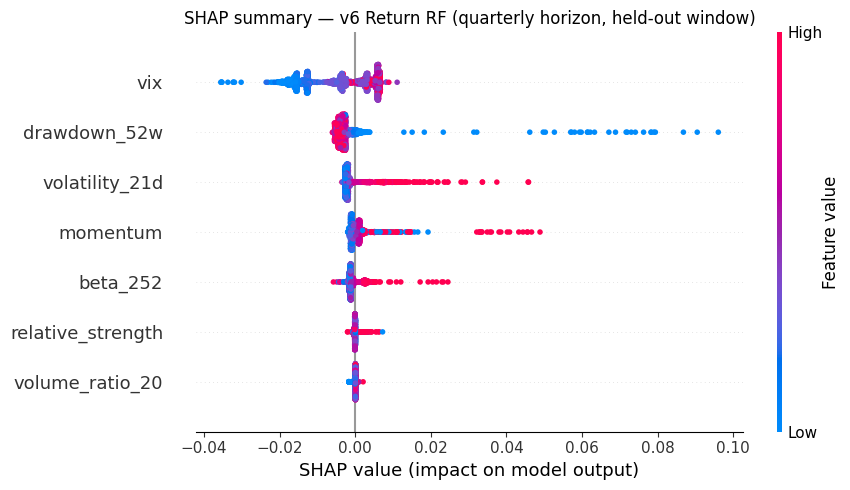

In [14]:
# SHAP summary plot (beeswarm), feature-by-feature distribution of attributions
fig, ax = plt.subplots(figsize=(9, 5))
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=FEATURE_COLS,
    show=False,
    plot_size=(9, 5),
)
plt.title('SHAP summary, v6 Return RF (quarterly horizon, held-out window)')
plt.tight_layout()
plt.show()

## 9. Preliminary discussion (Return RF v6)

Return RF v6 has been trained, evaluated, and SHAP-analysed above. The full v5→v6 comparison and the implications for the optimiser layer are written up in `docs/methodology.md` §4 after the full horizon refactor (Steps 1–10) completes. This notebook serves as the academic record of the v6 training procedure.

The next sections (§10–§16) cover the Volatility RF v6 retrain, same horizon (63 trading days), same purged 5-fold CV with 63-day embargo, same hyperparameter grid. Different target column (`forward_volatility`), different baseline (persistence rather than historical mean), different headline metric (top-quintile hit rate rather than directional accuracy).

---

# Step 3, Volatility RF v6 retrain

## 10. Train/test split for the volatility target

Reuses `tuning` and `held_out` from §2. Only the target column changes, from `forward_return` to `forward_volatility`. Both targets are produced by the same `build_features()` call (§1) and live in the same `features.parquet`.

Sanity-check that the rebuilt `forward_volatility` is on the 63-day window.

In [15]:
y_tune_vol = tuning['forward_volatility']
y_held_vol = held_out['forward_volatility']

print(f'Tuning   y_vol: {len(y_tune_vol):,} rows, mean {y_tune_vol.mean():.4f}, median {y_tune_vol.median():.4f}')
print(f'Held-out y_vol: {len(y_held_vol):,} rows, mean {y_held_vol.mean():.4f}, median {y_held_vol.median():.4f}')

# Spot-check that forward_volatility matches a manual rolling(63).std() * sqrt(252) for one ticker
sample_ticker = 'HSBA.L'
sample_date = feature_clean.xs(sample_ticker, level='ticker').index[-100]
daily_returns_manual = clean['Close'][sample_ticker].pct_change(fill_method=None)
manual_fwd_vol = daily_returns_manual.rolling(63).std().shift(-63) * np.sqrt(252)
fwd_vol_features = feature_clean.loc[(sample_date, sample_ticker), 'forward_volatility']
print(f'\nspot-check {sample_ticker} forward_volatility on {sample_date.date()}:')
print(f'  manual rolling(63).std() * sqrt(252): {manual_fwd_vol.loc[sample_date]:.6f}')
print(f'  features forward_volatility:          {fwd_vol_features:.6f}')
assert abs(manual_fwd_vol.loc[sample_date] - fwd_vol_features) < 1e-10, 'Vol target mismatch'
print('  match (within 1e-10): OK')

Tuning   y_vol: 191,245 rows, mean 0.2755, median 0.2444
Held-out y_vol: 51,243 rows, mean 0.2596, median 0.2419

spot-check HSBA.L forward_volatility on 2025-10-02:
  manual rolling(63).std() * sqrt(252): 0.232284
  features forward_volatility:          0.232284
  match (within 1e-10): OK


## 11. Volatility baseline, persistence

The persistence baseline for volatility is the trailing 63-day realised volatility at time `t`, used as the forecast for the forward 63-day realised volatility from `t` to `t+63`. Formally: `daily_returns.rolling(63).std() × √252`, evaluated at each `t` in the held-out window.

This is the analogue of the historical-mean baseline used for the Return RF. For volatility it is non-trivial because vol clusters serially (GARCH-type persistence), so the persistence baseline is the natural "trivial forecaster" the RF must beat. The v5 monthly run achieved persistence R² ≈ −0.36 on the held-out 2024+ window (the 2024 vol regime transition made simple persistence actively misleading).

In [16]:
# Compute the trailing 63-day realised vol from clean prices
daily_rets_all = clean['Close'].pct_change(fill_method=None)
trailing_63_vol_wide = daily_rets_all.rolling(63).std() * np.sqrt(252)
trailing_63_vol = trailing_63_vol_wide.stack(future_stack=True)
trailing_63_vol.index.names = ['date', 'ticker']

# Align to held-out (date, ticker) index; any missing values fall back to in-sample mean
persistence_pred = trailing_63_vol.reindex(y_held_vol.index)
fallback = y_tune_vol.mean()
persistence_pred = persistence_pred.fillna(fallback)

vol_rmse_baseline = float(np.sqrt(mean_squared_error(y_held_vol, persistence_pred)))
vol_mae_baseline = float(mean_absolute_error(y_held_vol, persistence_pred))
vol_r2_baseline = float(r2_score(y_held_vol, persistence_pred))

print(f'Persistence baseline on held-out (n = {len(y_held_vol):,}):')
print(f'  RMSE: {vol_rmse_baseline:.6f}')
print(f'  MAE:  {vol_mae_baseline:.6f}')
print(f'  R²:   {vol_r2_baseline:+.6f}   (negative ⇒ persistence is actively misleading on this window)')

Persistence baseline on held-out (n = 51,243):
  RMSE: 0.100905
  MAE:  0.070117
  R²:   -0.147005   (negative ⇒ persistence is actively misleading on this window)


## 12. Grid search, Volatility RF

Same hyperparameter grid as the Return RF (24 configurations × 5 folds = 120 fits). Same `PurgedTimeSeriesSplit` with `horizon_td=63, embargo_td=63`. Same Spearman ρ scoring.

**Runtime: ~55 minutes**, same as the Return RF grid above.

In [17]:
base_vol = RandomForestRegressor(n_estimators=500, random_state=42, n_jobs=-1)
cv_vol = PurgedTimeSeriesSplit(n_splits=N_SPLITS, horizon_td=HORIZON_TD, embargo_td=EMBARGO_TD)

grid_vol = GridSearchCV(
    estimator=base_vol,
    param_grid=GRID,
    cv=cv_vol,
    scoring=SPEARMAN_SCORER,
    n_jobs=1,
    verbose=1,
    refit=True,
)

X_tune_vol = tuning[FEATURE_COLS]   # same features as for return, only the target differs
X_held_vol = held_out[FEATURE_COLS]

t0 = time.time()
grid_vol.fit(X_tune_vol, y_tune_vol)
elapsed_min = (time.time() - t0) / 60
print(f'\nGrid search completed in {elapsed_min:.1f} minutes')
print(f'Best CV Spearman ρ: {grid_vol.best_score_:+.4f}')
print(f'Best params:        {grid_vol.best_params_}')

Fitting 5 folds for each of 24 candidates, totalling 120 fits

Grid search completed in 63.4 minutes
Best CV Spearman ρ: +0.5019
Best params:        {'max_depth': 8, 'max_features': 2, 'min_samples_leaf': 200}


In [18]:
# Top-10 ranking of all 24 configurations
cv_results_vol = pd.DataFrame(grid_vol.cv_results_)
param_cols_vol = [c for c in cv_results_vol.columns if c.startswith('param_')]
ranked_vol = cv_results_vol[param_cols_vol + ['mean_test_score', 'std_test_score', 'rank_test_score']].copy()
ranked_vol.columns = [c.replace('param_', '') for c in param_cols_vol] + ['mean_cv_rho', 'std_cv_rho', 'rank']
ranked_vol = ranked_vol.sort_values('rank').reset_index(drop=True)
print('Top 10 Volatility RF configurations by mean CV Spearman ρ:')
print(ranked_vol.head(10).to_string(index=False, float_format=lambda x: f'{x:+.4f}'))

Top 10 Volatility RF configurations by mean CV Spearman ρ:
 max_depth max_features  min_samples_leaf  mean_cv_rho  std_cv_rho  rank
         8            2               200      +0.5019     +0.1057     1
         8         sqrt               200      +0.5019     +0.1057     1
         8         sqrt               100      +0.5017     +0.1054     3
         8            2               100      +0.5017     +0.1054     3
         8            2                50      +0.4991     +0.1075     5
         8         sqrt                50      +0.4991     +0.1075     5
         5         sqrt               100      +0.4984     +0.1106     7
         5            2               100      +0.4984     +0.1106     7
         5            2                50      +0.4983     +0.1093     9
         5         sqrt                50      +0.4983     +0.1093     9


## 13. Held-out evaluation, Volatility RF v6

Reports RMSE, MAE, R², Spearman ρ, and **top-quintile hit rate**. Directional accuracy is not reported, degenerate for volatility (both predictions and realised values are non-negative).

Top-quintile hit rate = |stocks in predicted top-20% ∩ stocks in realised top-20%| / |realised top-20%|. Random baseline = 20% (uniform). v5 monthly achieved 44.3% on the same held-out window.

In [19]:
best_vol_model = grid_vol.best_estimator_
y_pred_vol = best_vol_model.predict(X_held_vol)
y_held_vol_arr = y_held_vol.to_numpy()

vol_rmse = float(np.sqrt(mean_squared_error(y_held_vol_arr, y_pred_vol)))
vol_mae = float(mean_absolute_error(y_held_vol_arr, y_pred_vol))
vol_r2 = float(r2_score(y_held_vol_arr, y_pred_vol))
vol_spear = spearman_score(y_held_vol_arr, y_pred_vol)


def top_quintile_hit_rate(y_true, y_pred):
    """|top-20% predicted ∩ top-20% actual| / |top-20% actual|."""
    n = len(y_true)
    k = max(1, n // 5)
    pred_top = set(np.argsort(-y_pred)[:k])
    actual_top = set(np.argsort(-y_true)[:k])
    return float(len(pred_top & actual_top) / len(actual_top))


vol_hit_rate = top_quintile_hit_rate(y_held_vol_arr, y_pred_vol)

print(f'Held-out evaluation (2024-01-01 onwards, n = {len(y_held_vol_arr):,}):\n')
print(f'  RMSE:                   {vol_rmse:.6f}    (persistence baseline {vol_rmse_baseline:.6f})')
print(f'  MAE:                    {vol_mae:.6f}    (persistence baseline {vol_mae_baseline:.6f})')
print(f'  R²:                     {vol_r2:+.6f}    (persistence baseline {vol_r2_baseline:+.6f})')
print(f'  Spearman ρ:             {vol_spear:+.6f}')
print(f'  Top-quintile hit rate:  {vol_hit_rate:.4f}    (random baseline 0.200)')

# Sanity-check bounds from Kai's brief Step 3
print('\nSanity checks (per Step 3 brief, vol R² expected in 0.10–0.40):')
if vol_r2 > 0.40:
    print(f'  WARN: R² {vol_r2:+.4f} > 0.40, at the upper edge of the expected range; review for leakage')
elif vol_r2 < 0.10:
    print(f'  NOTE: R² {vol_r2:+.4f} below 0.10, weaker than typical vol prediction')
else:
    print(f'  OK:   R² {vol_r2:+.4f} in expected vol range [0.10, 0.40]')

Held-out evaluation (2024-01-01 onwards, n = 51,243):

  RMSE:                   0.087006    (persistence baseline 0.100905)
  MAE:                    0.063390    (persistence baseline 0.070117)
  R²:                     +0.147226    (persistence baseline -0.147005)
  Spearman ρ:             +0.459204
  Top-quintile hit rate:  0.4518    (random baseline 0.200)

Sanity checks (per Step 3 brief — vol R² expected in 0.10–0.40):
  OK:   R² +0.1472 in expected vol range [0.10, 0.40]


In [20]:
# Save the v6 Volatility RF artefact
vol_model_path = Path('../models/rf_volatility_v6.joblib')
joblib.dump(best_vol_model, vol_model_path)
print(f'Saved: {vol_model_path}')

Saved: ../models/rf_volatility_v6.joblib


## 14. v5 (monthly) vs v6 (quarterly), Volatility RF comparison

v5 figures reproduced from the prior held-out evaluation documented in `docs/methodology.md` §4.4. Hyperparameters for v5 were `max_depth=8, min_samples_leaf=50, max_features=2, n_estimators=500`.

In [21]:
v5_vol_metrics = {
    'RMSE':                  0.1150,
    'MAE':                   0.0768,
    'R²':                    0.0710,
    'Spearman ρ':            0.4490,
    'Top-quintile hit rate': 0.4430,
}
v5_vol_baselines = {
    'RMSE (persistence)':            0.1391,
    'R² (persistence)':             -0.3590,
    'Top-quintile hit rate (random)': 0.2000,
}
v6_vol_metrics = {
    'RMSE': vol_rmse, 'MAE': vol_mae, 'R²': vol_r2,
    'Spearman ρ': vol_spear, 'Top-quintile hit rate': vol_hit_rate,
}
v6_vol_baselines = {
    'RMSE (persistence)': vol_rmse_baseline,
    'R² (persistence)':   vol_r2_baseline,
    'Top-quintile hit rate (random)': 0.2000,
}

comparison_vol = pd.DataFrame({
    'v5 (monthly)':    v5_vol_metrics,
    'v6 (quarterly)':  v6_vol_metrics,
})
baselines_vol = pd.DataFrame({
    'v5 (monthly)':    v5_vol_baselines,
    'v6 (quarterly)':  v6_vol_baselines,
})

print('Volatility RF metrics:')
print(comparison_vol.to_string(float_format=lambda x: f'{x:+.4f}'))
print('\nVolatility RF baselines:')
print(baselines_vol.to_string(float_format=lambda x: f'{x:+.4f}'))

Volatility RF metrics:
                       v5 (monthly)  v6 (quarterly)
RMSE                        +0.1150         +0.0870
MAE                         +0.0768         +0.0634
R²                          +0.0710         +0.1472
Spearman ρ                  +0.4490         +0.4592
Top-quintile hit rate       +0.4430         +0.4518

Volatility RF baselines:
                                v5 (monthly)  v6 (quarterly)
RMSE (persistence)                   +0.1391         +0.1009
R² (persistence)                     -0.3590         -0.1470
Top-quintile hit rate (random)       +0.2000         +0.2000


## 15. SHAP analysis on the v6 Volatility RF

Mirrors §8's approach for the Return RF: same monthly cross-section sample from the held-out window, same `tree_path_dependent` perturbation, same mean-|SHAP| ranking + summary plot. The vol model's expected feature importance pattern is different from the return model's, the literature predicts `volatility_21d` and `vix` carry the most signal for forward vol (GARCH-style persistence + market-regime sensitivity).

In [22]:
# Reuse the X_shap sample built in §8 for direct comparability
explainer_vol = shap.TreeExplainer(best_vol_model, feature_perturbation='tree_path_dependent')

t0 = time.time()
shap_values_vol = explainer_vol.shap_values(X_shap)
base_value_vol = float(np.asarray(explainer_vol.expected_value).flat[0])
predictions_vol = best_vol_model.predict(X_shap)
print(f'SHAP computed in {time.time()-t0:.1f}s for {X_shap.shape}')
print(f'base_value (model mean prediction): {base_value_vol:+.6f}')

reconstructed_vol = base_value_vol + shap_values_vol.sum(axis=1)
max_residual_vol = float(np.max(np.abs(reconstructed_vol - predictions_vol)))
print(f'Additivity check: max |reconstructed - prediction| = {max_residual_vol:.2e}')
assert max_residual_vol < 1e-5, 'SHAP additivity violated for Vol RF'
print('SHAP additivity: OK')

SHAP computed in 33.8s for (2418, 7)
base_value (model mean prediction): +0.275539
Additivity check: max |reconstructed - prediction| = 2.66e-15
SHAP additivity: OK


In [23]:
mean_abs_shap_vol = pd.Series(
    np.abs(shap_values_vol).mean(axis=0),
    index=FEATURE_COLS,
    name='mean_|SHAP|',
).sort_values(ascending=False)

print('Mean |SHAP| feature ranking (v6 Volatility RF, held-out monthly cross-sections):')
for feat, val in mean_abs_shap_vol.items():
    print(f'  {feat:22s}  {val:.6f}')

# Side-by-side with the Return RF ranking from §8
side_by_side = pd.DataFrame({
    'Return RF (mean |SHAP|)':     mean_abs_shap,
    'Volatility RF (mean |SHAP|)': mean_abs_shap_vol,
})
print('\nReturn RF vs Volatility RF, mean |SHAP| by feature:')
print(side_by_side.to_string(float_format=lambda x: f'{x:.6f}'))

Mean |SHAP| feature ranking (v6 Volatility RF, held-out monthly cross-sections):
  volatility_21d          0.022327
  drawdown_52w            0.014797
  beta_252                0.013167
  momentum                0.006712
  relative_strength       0.002298
  vix                     0.002205
  volume_ratio_20         0.001073

Return RF vs Volatility RF — mean |SHAP| by feature:
                   Return RF (mean |SHAP|)  Volatility RF (mean |SHAP|)
beta_252                          0.001526                     0.013167
drawdown_52w                      0.004117                     0.014797
momentum                          0.001567                     0.006712
relative_strength                 0.000154                     0.002298
vix                               0.008103                     0.002205
volatility_21d                    0.002931                     0.022327
volume_ratio_20                   0.000083                     0.001073


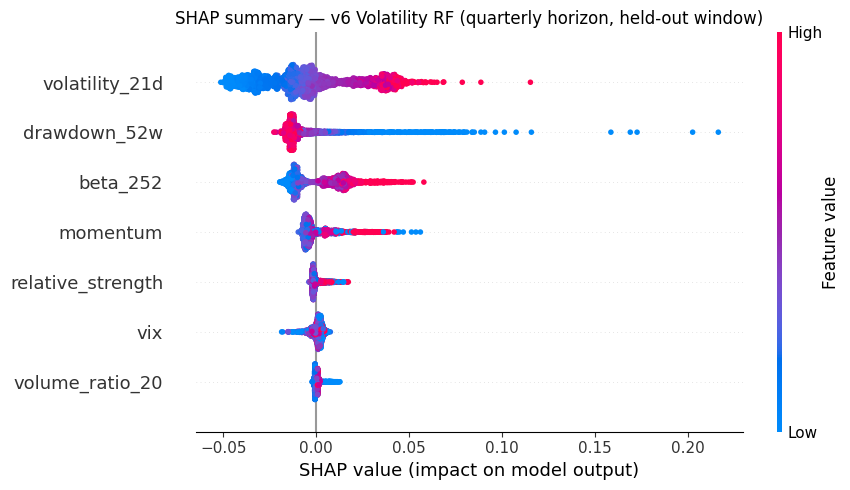

In [24]:
fig, ax = plt.subplots(figsize=(9, 5))
shap.summary_plot(
    shap_values_vol,
    X_shap,
    feature_names=FEATURE_COLS,
    show=False,
    plot_size=(9, 5),
)
plt.title('SHAP summary, v6 Volatility RF (quarterly horizon, held-out window)')
plt.tight_layout()
plt.show()

## 16. Discussion + next steps

**Step 2 (Return RF v6)** and **Step 3 (Volatility RF v6)** of the horizon refactor are complete in this notebook. Both models are saved to `../models/rf_*_v6.joblib`.

**Pending downstream work** (separate from this notebook):
- Step 4, confirm the covariance estimator's scaling matches the new horizon (`src/models/optimise.py`).
- Step 5, re-run the historical backtest at quarterly rebalance cadence using v6 models (`notebooks/allocation_validation.ipynb` extended or replaced).
- Step 6, update Monte Carlo projection to quarterly steps (`src/models/project.py` + `pages/6_backtest.py`).
- Step 7, UI label updates (~14 strings across `pages/`).
- Step 8, event-log schema diff.
- Step 9, methodology + ethics document phrase list.
- Step 10, summary report.

The v6 hyperparameters discovered above will need to be referenced in `docs/methodology.md` §4.3 (the locked-hyperparameter table) at Step 9 and in `memory/project_decisions.md` at Step 10.